In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()

# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 6

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

# b = np.array([0]+[1]*47+[2]*5+[0]*11])

c = 1e-0
v0 = 1
y = 1
b = np.array([0,c,0,0,0,0,0,0,0,0,0,0,0,0,0,c+v0*y]*4)
b=b/np.linalg.norm(b)

In [3]:
np.linalg.det(m)



64.0000000000006

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([-4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106e-48-5.47382213e-48j,
       -1.38777878e-17+2.77555756e-17j, -9.24446373e-33-6.16297582e-33j,
       -9.71445147e-17+2.77555756e-17j,  4.47213595e-01+1.11022302e-16j,
       -4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(p,q,i,j,k,l):
        return np.kron(p,np.kron(q,np.kron(i,np.kron(j,np.kron(k,l)))))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,z,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,z,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I,I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([1.19438555e+01-7.38613527e-17j, 1.02720576e+01-1.01338444e-16j,
       9.53474181e+00+3.72030325e-17j, 9.41120780e+00-2.64948304e-16j,
       9.41197035e+00-1.80457166e-16j, 7.84502294e+00+1.33030750e-16j,
       7.85230899e+00-1.09515188e-16j, 7.59827678e+00-1.08292917e-16j,
       7.36664009e+00+4.75848205e-17j, 7.32856677e+00+3.04297446e-16j,
       6.66866485e+00-6.71712204e-17j, 6.91869854e+00+3.39364575e-16j,
       5.71307232e+00+1.89922092e-16j, 5.59214491e+00+9.92908828e-17j,
       5.40275653e+00-1.13857358e-16j, 5.49187388e+00-7.49779599e-17j,
       5.15184720e+00-1.64042214e-16j, 4.99510578e+00+2.09111212e-16j,
       4.77978056e+00-1.61647946e-16j, 4.46809557e+00+5.77520109e-17j,
       3.98589495e+00+1.21835475e-16j, 3.64211313e+00-1.54516542e-17j,
       3.47181375e+00+5.04103487e-16j, 3.42929703e+00-1.81471538e-16j,
       3.28207514e+00-5.33866575e-17j, 2.99982107e+00-1.98443495e-16j,
       2.56948109e+00+3.76719087e-17j, 2.40233999e+00-3.15847538e-16j,
      

In [7]:
U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
U9=scl.expm(2**8*2*np.pi*1j*A) 
U10=scl.expm(2**9*2*np.pi*1j*A) 
U11=scl.expm(2**10*2*np.pi*1j*A) 
U12=scl.expm(2**11*2*np.pi*1j*A)
U13=scl.expm(2**12*2*np.pi*1j*A) 
U14=scl.expm(2**13*2*np.pi*1j*A) 
U15=scl.expm(2**14*2*np.pi*1j*A)
U16=scl.expm(2**15*2*np.pi*1j*A) 

 
u1gate=UnitaryGate(U1)
u2gate=UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)
u9gate=UnitaryGate(U9)
u10gate=UnitaryGate(U10)
u11gate=UnitaryGate(U11)
u12gate=UnitaryGate(U12)
u13gate=UnitaryGate(U13)
u14gate=UnitaryGate(U14)
u15gate=UnitaryGate(U15)
u16gate=UnitaryGate(U16)



In [8]:
Id = np.identity(2**nb_qubits)
z0 = np.array([[1,0],
               [0,0]])
z1 = np.array([[0,0],
               [0,1]])

CU1 = np.kron(Id,z0) + np.kron(U1,z1)
CU2 = np.kron(Id,z0) + np.kron(U2,z1)
CU3 = np.kron(Id,z0) + np.kron(U3,z1)
CU4 = np.kron(Id,z0) + np.kron(U4,z1)
CU5 = np.kron(Id,z0) + np.kron(U5,z1)
CU6 = np.kron(Id,z0) + np.kron(U6,z1)
CU7 = np.kron(Id,z0) + np.kron(U7,z1)
CU8 = np.kron(Id,z0) + np.kron(U8,z1)
CU9 = np.kron(Id,z0) + np.kron(U9,z1)
CU10 = np.kron(Id,z0) + np.kron(U10,z1)
CU11 = np.kron(Id,z0) + np.kron(U11,z1)
CU12 = np.kron(Id,z0) + np.kron(U12,z1)
CU13 = np.kron(Id,z0) + np.kron(U13,z1)
CU14 = np.kron(Id,z0) + np.kron(U14,z1)
CU15 = np.kron(Id,z0) + np.kron(U15,z1)
CU16 = np.kron(Id,z0) + np.kron(U16,z1)




C_u1gate=UnitaryGate(CU1)
C_u2gate=UnitaryGate(CU2)
C_u3gate=UnitaryGate(CU3)
C_u4gate=UnitaryGate(CU4)
C_u5gate=UnitaryGate(CU5)
C_u6gate=UnitaryGate(CU6)
C_u7gate=UnitaryGate(CU7)
C_u8gate=UnitaryGate(CU8)
C_u9gate=UnitaryGate(CU9)
C_u10gate=UnitaryGate(CU10)
C_u11gate=UnitaryGate(CU11)
C_u12gate=UnitaryGate(CU12)
C_u13gate=UnitaryGate(CU13)
C_u14gate=UnitaryGate(CU14)
C_u15gate=UnitaryGate(CU15)
C_u16gate=UnitaryGate(CU16)


[0.17286133 0.12244153 0.13049922 0.19296309 0.52540844 0.39856645
 0.85690314 0.19894652 0.52757741 0.75097524 0.62621902 0.10408361
 0.84975224 0.78617069 0.97538879 0.08512419 0.47087014 0.97021634
 0.42546707 0.74564921 0.34380603 0.80570861 0.75927679 0.25372411
 0.93635803 0.60633748 0.42715002 0.5753946  0.69165086 0.65769128
 0.8488759  0.61142265 0.67476757 0.03506587 0.35111507 0.61801076
 0.6487269  0.51303413 0.89244265 0.05177995 0.68898346 0.65066658
 0.03191173 0.48593032 0.58740411 0.35855259 0.98600749 0.89104713
 0.92011771 0.23875365 0.98561524 0.17592047 0.53497773 0.12010742]


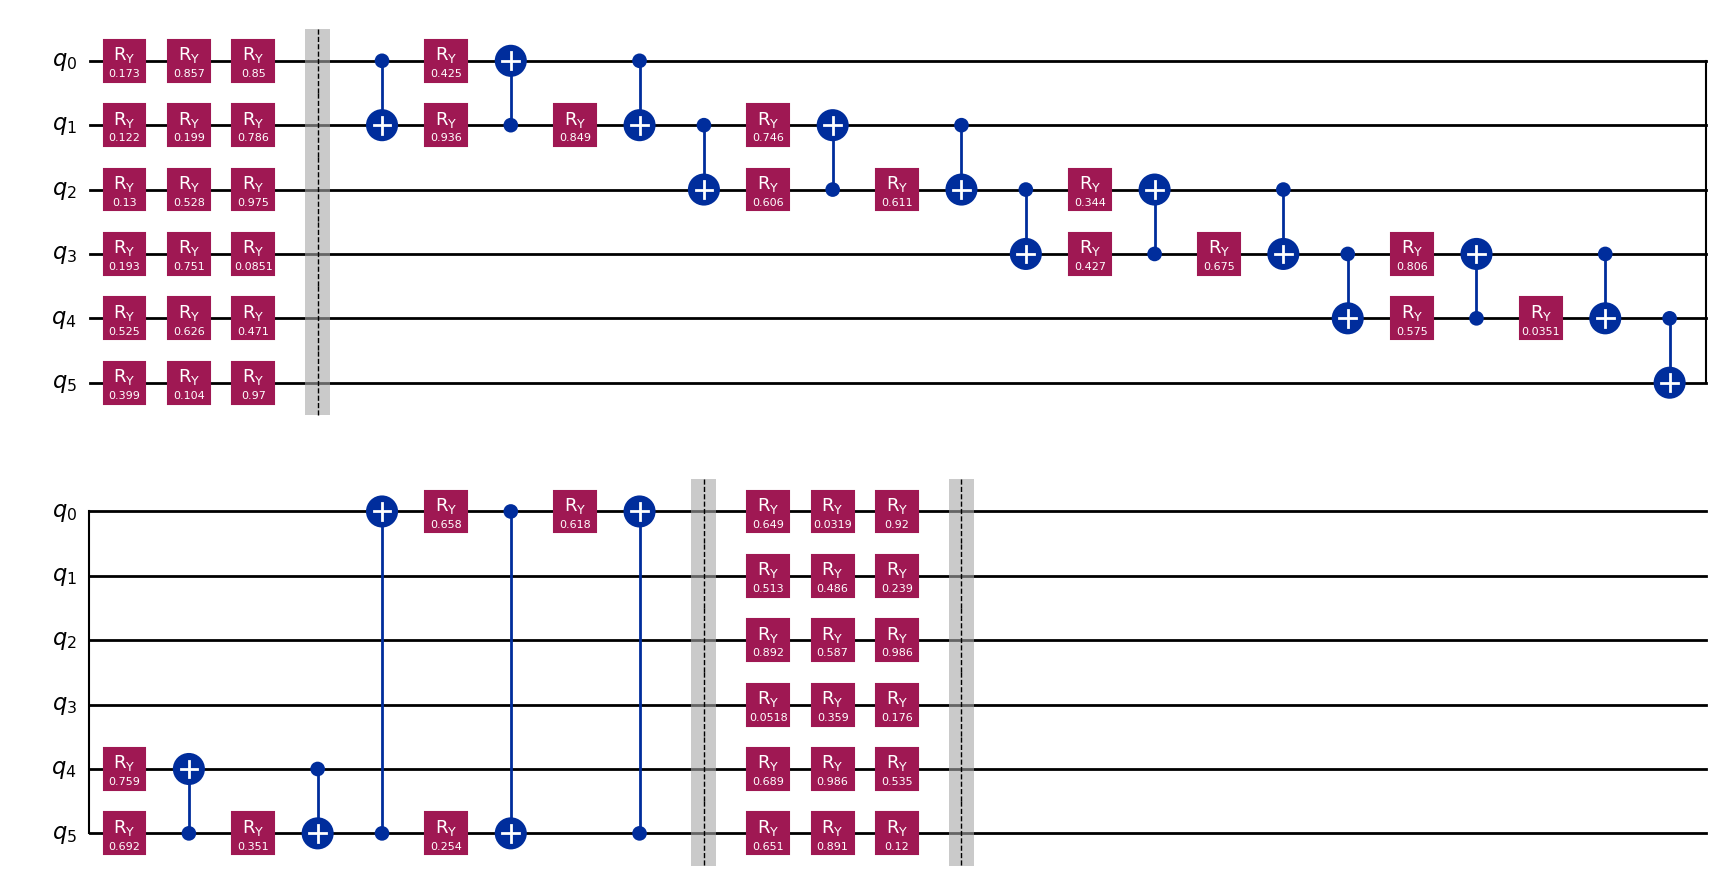

In [9]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc


depth=1
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
# Parameters = np.array([random.random() for _ in range(0, nb_params)])

Parameters = np.array([0.17286133, 0.12244153, 0.13049922, 0.19296309, 0.52540844, 0.39856645,
 0.85690314, 0.19894652, 0.52757741, 0.75097524, 0.62621902, 0.10408361,
 0.84975224, 0.78617069, 0.97538879, 0.08512419, 0.47087014, 0.97021634,
 0.42546707, 0.74564921, 0.34380603, 0.80570861, 0.75927679, 0.25372411,
 0.93635803, 0.60633748, 0.42715002, 0.5753946 , 0.69165086, 0.65769128,
 0.8488759,  0.61142265, 0.67476757, 0.03506587, 0.35111507, 0.61801076,
 0.6487269,  0.51303413, 0.89244265, 0.05177995, 0.68898346, 0.65066658,
 0.03191173, 0.48593032, 0.58740411, 0.35855259, 0.98600749, 0.89104713,
 0.92011771, 0.23875365, 0.98561524, 0.17592047, 0.53497773, 0.12010742])
print(Parameters)
ansatz(Parameters).draw("mpl")

In [11]:
def circ(Parameters):
    x=QuantumRegister(22)
    c=ClassicalRegister(16)
    circuit = QuantumCircuit(x,c)
    circuit=circuit.compose(ansatz(Parameters),x[16:22])
    circuit.h(x[0:16])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u2gate, [x[1],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u3gate, [x[2],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u4gate, [x[3],x[16],x[17],x[18],x[19],x[20],x[21]])  
    circuit.append(C_u5gate, [x[4],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u6gate, [x[5],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u7gate, [x[6],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u8gate, [x[7],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u9gate, [x[8],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u10gate, [x[9],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u11gate, [x[10],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u12gate, [x[11],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u13gate, [x[12],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u14gate, [x[13],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u15gate, [x[14],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u16gate, [x[15],x[16],x[17],x[18],x[19],x[20],x[21]])    
    # circuit.append(C_u17, [x[16],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])    
    # circuit.append(C_u18, [x[17],x[18],x[19],x[20],x[21],x[22],x[23],x[24],x[25]])
#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True, 
                   inverse = True, insert_barriers = False, name ='qftinv')
    circuit.measure(x[0:16],c)       
    return circuit

/tmp/ipykernel_1770255/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


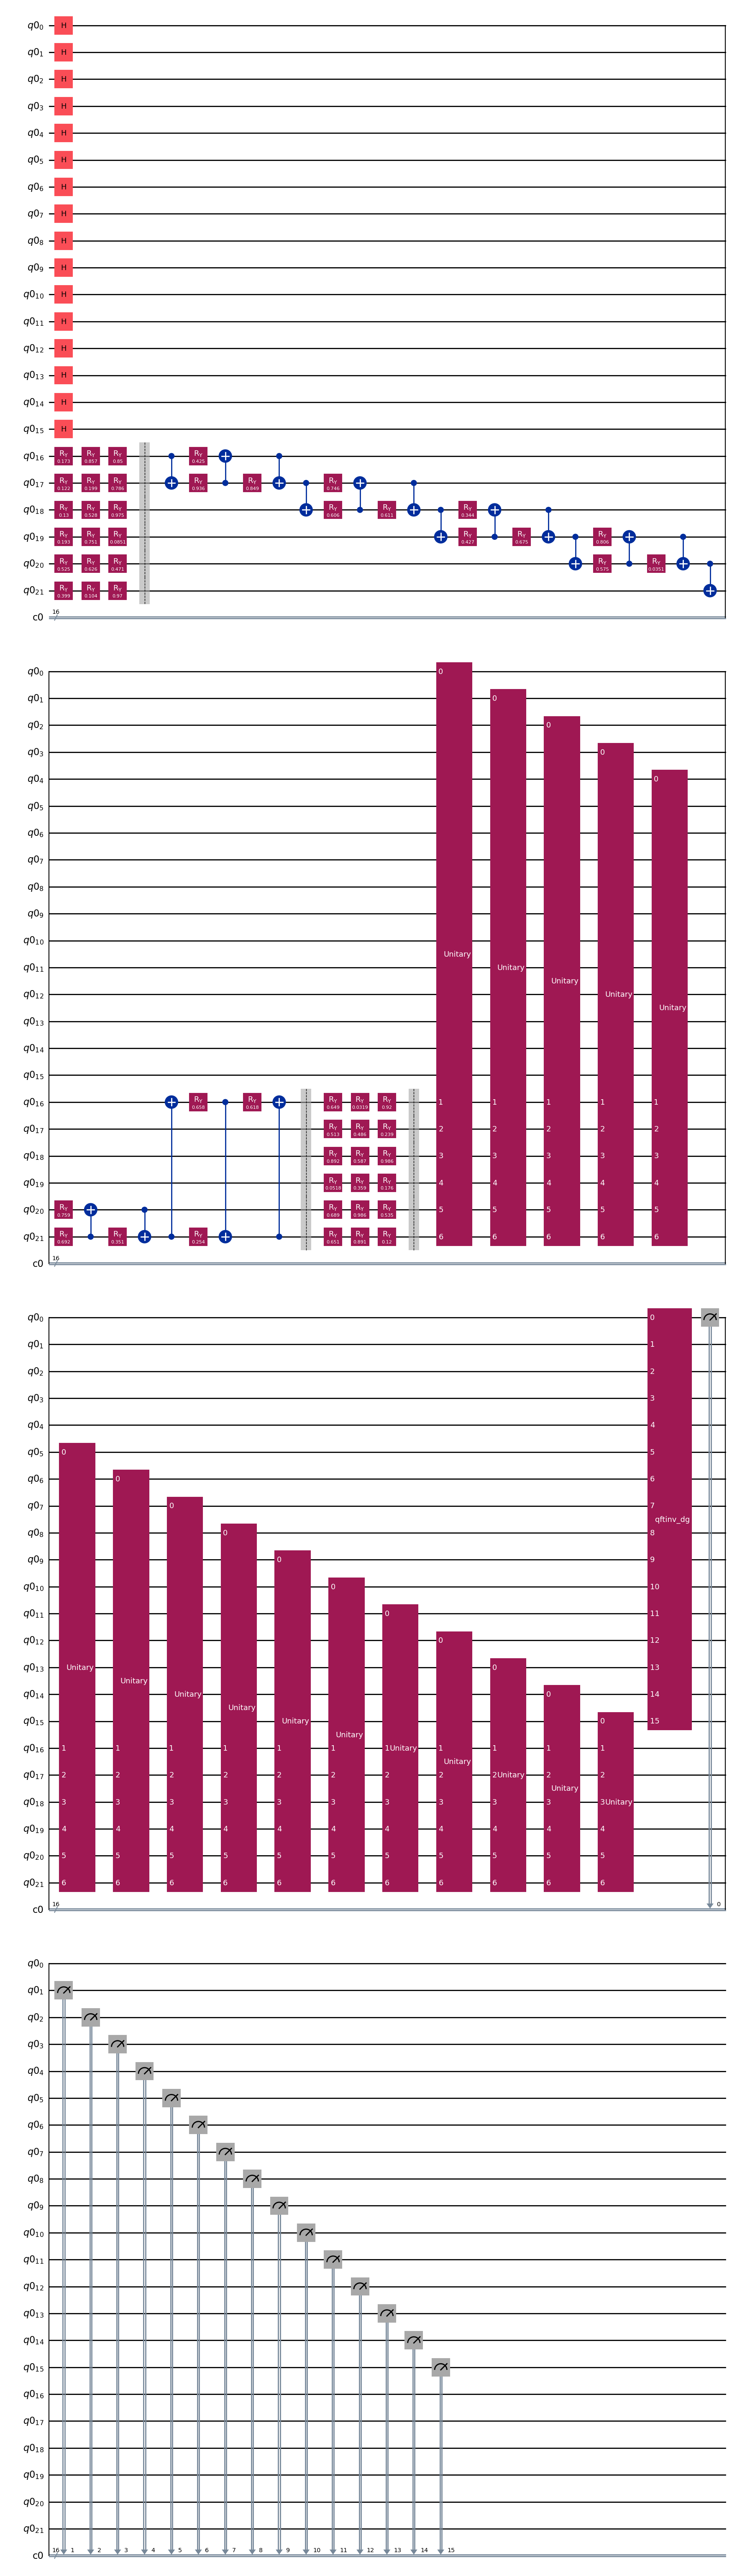

In [13]:
circ(Parameters).draw("mpl") 

In [14]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '0000000000000000'not in result: 
        res = 1
    else:
        res = 1 - result['0000000000000000']/shots
    return res
cost(Parameters)


/tmp/ipykernel_1770255/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


0.99469

In [15]:
from scipy.optimize import minimize
def save(Parameters):
    global Cost,Params
    Cost.append(cost(Parameters))
    Params.append(Parameters)
    print(cost(Parameters))
Cost = []
Params = []
minimize(cost, x0 = Parameters,callback = save, method="cobyla",
              options = {'maxiter':6000})
    
    
    

/tmp/ipykernel_1770255/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


0.99192
0.97797
0.98826
0.98975
0.98505
0.96738
0.98071
0.98019
0.98723
0.99488
0.98242
0.97204
0.98155
0.98038
0.98675
0.99483
0.98212
0.97285
0.98534
0.9867900000000001
0.99481
0.97095
0.95244
0.97093
0.97714
0.96662
0.99084
0.98326
0.9745
0.97905
0.96252
0.97419
0.94506
0.97011
0.95298
0.92799
0.95148
0.98351
0.99557
0.97979
0.99405
0.98355
0.95299
0.98425
0.996
0.97982
0.99394
0.98389
0.95189
0.98392
0.9959
0.97833
0.9931
0.98346
0.63515
0.98708
0.6823699999999999
0.65974
0.58414
0.63838
0.66072
0.55419
0.58036
0.59571
0.5533600000000001
0.62967
0.644
0.56145
0.53064
0.6006
0.579
0.5496
0.5741499999999999
0.5703400000000001
0.5303899999999999
0.41145
0.44406999999999996
0.62694
0.46126
0.47158999999999995
0.40532999999999997
0.40293
0.40042
0.57795
0.38593
0.6488700000000001
0.45043999999999995
0.51372
0.42064
0.47902
0.38919000000000004
0.7231000000000001
0.41142
0.6137699999999999
0.38693
0.65309
0.49084000000000005
0.4112
0.48660000000000003
0.39651000000000003
0.35061
0.3706500

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.02454999999999996
       x: [ 3.179e-01  9.221e-01 ...  3.894e-03  6.034e-01]
    nfev: 1017
   maxcv: 0.0

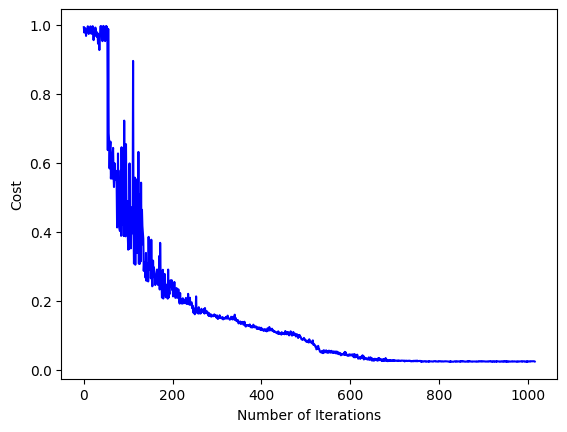

In [16]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [17]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [18]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

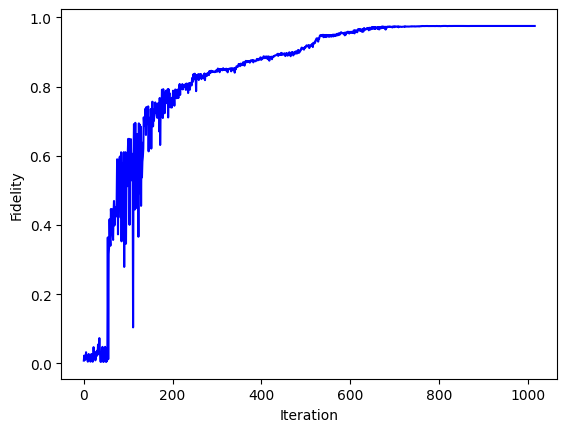

In [19]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [20]:
norm_e[np.argmax(F)]

4.9955491095278175

In [21]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.05060633, 0.21263052, 0.03093464, 0.26313459, 0.16882763,
       0.23312217, 0.13364072, 0.29981341, 0.35596444, 0.31168618,
       0.36615945, 0.44224591, 0.65189749, 0.49930094, 0.64272567,
       0.647378  , 0.89980364, 0.91424922, 0.86715253, 0.92342147,
       0.86763237, 0.76974993, 0.84973517, 0.82406286, 0.73253566,
       0.77381951, 0.7163422 , 0.76634751, 0.70775134, 0.63337386,
       0.70408115, 0.66448201, 0.71613333, 0.86211428, 0.71463027,
       0.86163106, 0.677806  , 0.85438559, 0.70440761, 0.87248035,
       0.80419995, 0.76619788, 0.78242378, 0.79647729, 0.82642232,
       0.79398928, 0.82335563, 0.84270005, 0.46774011, 0.43541365,
       0.44953544, 0.4477744 , 0.46407782, 0.38252901, 0.45349847,
       0.41533468, 0.39773616, 0.31715913, 0.36543547, 0.32039185,
       0.35274966, 0.21375134, 0.32510889, 0.23617451])

In [23]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [24]:
abs(np.array(e[-1]))

array([0.04843568, 0.20556173, 0.02571138, 0.25091163, 0.15812672,
       0.22251728, 0.12147156, 0.28327277, 0.33406539, 0.29621339,
       0.33568088, 0.41442462, 0.61102553, 0.47196505, 0.59548313,
       0.60720964, 0.84063275, 0.86249421, 0.81311191, 0.87443012,
       0.80823514, 0.72272725, 0.7919378 , 0.77489353, 0.68165616,
       0.727938  , 0.66948341, 0.72385331, 0.65677847, 0.5921731 ,
       0.653945  , 0.62240937, 0.66764277, 0.80700266, 0.66824597,
       0.81020275, 0.63052075, 0.79844573, 0.6558765 , 0.81661283,
       0.75390436, 0.71769785, 0.73376488, 0.74904135, 0.77435071,
       0.74320328, 0.77043162, 0.7897177 , 0.4358457 , 0.40527206,
       0.42213988, 0.42071864, 0.43333294, 0.35598028, 0.42515691,
       0.38907544, 0.37306757, 0.29637525, 0.34672529, 0.3041423 ,
       0.33173318, 0.19943951, 0.30811407, 0.223689  ])

In [25]:
X_opt

array([0.00855052+0.j, 0.03810055+0.j, 0.00783717+0.j, 0.04907882+0.j,
       0.03418541+0.j, 0.04703875+0.j, 0.03068704+0.j, 0.06073663+0.j,
       0.07118948+0.j, 0.06599357+0.j, 0.07444716+0.j, 0.08983432+0.j,
       0.12602723+0.j, 0.10296463+0.j, 0.12625596+0.j, 0.12981233+0.j,
       0.17185409+0.j, 0.17654811+0.j, 0.16833947+0.j, 0.17967318+0.j,
       0.16849653+0.j, 0.1539105 +0.j, 0.16663748+0.j, 0.16413758+0.j,
       0.14818704+0.j, 0.15686633+0.j, 0.14705612+0.j, 0.15716322+0.j,
       0.14583125+0.j, 0.13493522+0.j, 0.14634902+0.j, 0.14129091+0.j,
       0.14913361+0.j, 0.17359279+0.j, 0.14862931+0.j, 0.17322118+0.j,
       0.141033  +0.j, 0.17020913+0.j, 0.1445726 +0.j, 0.17247969+0.j,
       0.16094128+0.j, 0.15408134+0.j, 0.15644944+0.j, 0.15867798+0.j,
       0.16267767+0.j, 0.15671083+0.j, 0.16104928+0.j, 0.16398565+0.j,
       0.10039558+0.j, 0.09387853+0.j, 0.09541074+0.j, 0.09371432+0.j,
       0.09449564+0.j, 0.07939477+0.j, 0.09016124+0.j, 0.08234613+0.j,
      

In [26]:
print(F)

[0.00793529808502693, 0.02259463717788929, 0.011633799244572102, 0.009888026203526403, 0.014931550673044733, 0.032166237180962655, 0.018350916982139365, 0.01969724085008593, 0.012633251632699, 0.004980172838845028, 0.017928338366412125, 0.02705131243796841, 0.018350916982139403, 0.019697240850085906, 0.012633251632699011, 0.00498017283884503, 0.017928338366412118, 0.0270513124379684, 0.014227875464345561, 0.012758879873812832, 0.004722679223174271, 0.028198909247584853, 0.04687230522029454, 0.029162735860329123, 0.022672148762972532, 0.033395924174505306, 0.008781989749687705, 0.01706331830024167, 0.02531362194599956, 0.021141945290745177, 0.03666155799108054, 0.02470738089242756, 0.054320327160097714, 0.030096752437718158, 0.046660428186164955, 0.07300834534130958, 0.047705454913717305, 0.016160717572785394, 0.004160174273663793, 0.02114010936337266, 0.006048386383573001, 0.015802754189954284, 0.047705454913717284, 0.01616071757278538, 0.004160174273663798, 0.02114010936337266, 0.0060

In [27]:
print(norm_e)

[3.6409571050817497, 4.224292417026482, 5.528008289335272, 5.351555176003359, 7.028030595202291, 11.679287091978154, 8.59149556297885, 24.05438115456507, 13.152117482792073, 15.462479327431797, 14.22501859625418, 9.887550393804212, 8.591495562978851, 24.054381154565117, 13.15211748279207, 15.462479327431808, 14.225018596254186, 9.887550393804199, 9.363443659601085, 11.511534368393908, 17.675074321618215, 12.758639671100019, 3.9732148529376308, 5.112169421906135, 3.3648764363850945, 4.35290493449908, 4.862426570258798, 3.676190555749325, 5.911860723103358, 3.870732655677564, 6.160314530771188, 4.116012290570316, 4.594027796101914, 5.103740858728469, 17.964882755118268, 41.46198795322247, 3.0590939417836873, 375.325857706633, 12.762288517439423, 30.907007307388263, 6.652231861911755, 8.634968591665817, 3.059093941783689, 375.32585770663053, 12.762288517439437, 30.90700730738832, 6.652231861911762, 8.63496859166582, 3.059093941783687, 375.32585770663445, 12.762288517439435, 30.90700730738

In [28]:
min(norm_e)

2.184236576362706

In [29]:
1-max(F)

0.02444677507533477